---
title: Assignment-2
author: Siddharth Rajesh
date: 18-02-2026
---

## Import our libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from gprofiler import GProfiler

# Data Analysis

## Loading the data

In [2]:
data = pd.read_table('./data/DecayTimecourse.txt', sep = '\t')
print(data.head())  # Inspecting the first 5 rows of the data
print(data.shape)   # inspecting the dimensions of the data

  Time course #  timecourse1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5  \
0          YORF          0.0    5.000000    10.00000   15.000000        20.0   
1       YAL026C          1.0    0.703032         NaN         NaN         NaN   
2       YDR148C          NaN         NaN         NaN         NaN         NaN   
3       YIL125W          1.0    1.176639     0.82317    0.556528         NaN   
4       YLR240W          NaN         NaN         NaN         NaN         NaN   

   Unnamed: 6  Unnamed: 7  Unnamed: 8  Unnamed: 9  ...  Unnamed: 18  \
0   30.000000   40.000000   50.000000   60.000000  ...    60.000000   
1    0.713088    0.332218    0.215325    0.226495  ...          NaN   
2         NaN         NaN         NaN         NaN  ...     0.374799   
3    0.712678    0.427962    0.320204    0.276578  ...          NaN   
4         NaN         NaN         NaN         NaN  ...          NaN   

   timecourse3  Unnamed: 20  Unnamed: 21  Unnamed: 22  Unnamed: 23  \
0          0.0     5.0

### Splitting the data among the 3 replicates

In [3]:
rep1 = data.iloc[1:, 1:10].copy()  # Making a copy of columns 2-11
rep2 = data.iloc[1:, 10:19].copy() # Making a copy of columns 12-21
rep3 = data.iloc[1:, 19:28].copy() # Making a copy of columns 22-30
print(rep1.shape, rep2.shape, rep3.shape)

time_points = [0, 5, 10, 15, 20, 30, 40, 50, 60]
rep1.columns = time_points  # Setting the column names to be time point at which the gene was measured
rep2.columns = time_points
rep3.columns = time_points

(6184, 9) (6184, 9) (6184, 9)


## Defining the function to calculate the half-life for the 3 replicates

In [4]:
def exp_decay(time, initial, rate):
    return initial * np.exp(-rate * time)   # Function for exponential decay

def half_life(rate):
    return np.log(2) / rate                 # Function for calculating half-life

def calculate_half_life(time_points, values):
    """
    Fit exponential decay to the data and return half-life.
    Half-life = ln(2)/lambda
    """
    # Drop NaN values
    mask = ~np.isnan(values)           # Identify the indices where the value is not NA
    t = np.array(time_points)[mask]    # Masking the NA values in the time points
    y = np.array(values)[mask]         # Masking the NA values in the time series data
    
    if len(t) < 3:
        return np.nan
    
    # Remove non-positive values (can't fit exponential to <= 0)
    pos_mask = y > 0         # Mask for negative values in the time-series
    t = t[pos_mask]
    y = y[pos_mask]
    
    if len(t) < 3:
        return np.nan
    
    try:
        popt, _ = curve_fit(exp_decay, t, y, maxfev = 10000, bounds=([0, 0], [np.inf, np.inf]), p0=[1.0, 0.01]) # Fit the time-series data into the exponential function
        lam = popt[1]          # Extract the 2nd coefficient in the model which is lambda
        if lam > 0:
            return half_life(lam)    # Calculating the half-life from the lambda
        return np.nan    
    except: 
        return np.nan


### Calculating the half-life of each gene among the 3 transcripts and storing it in a dictionary

In [5]:
half_lives = {'gene': [], 'hl_rep1': [], 'hl_rep2': [], 'hl_rep3': []}

genes = data.iloc[1:, 0]

for i in range(len(genes)):
    half_lives['gene'].append(genes.iloc[i])
    
    vals1 = rep1.iloc[i].values.astype(float)   # Extracting the values alone for fitting into the exponential decay model
    vals2 = rep2.iloc[i].values.astype(float)
    vals3 = rep3.iloc[i].values.astype(float)
    
    half_lives['hl_rep1'].append(calculate_half_life(time_points, vals1))
    half_lives['hl_rep2'].append(calculate_half_life(time_points, vals2))
    half_lives['hl_rep3'].append(calculate_half_life(time_points, vals3))

### Converting the dictionary into a Data Frame

In [6]:
halflife_df = pd.DataFrame(half_lives)   # Converting the dictionary into a DataFrame
print(halflife_df)

         gene    hl_rep1    hl_rep2    hl_rep3
0     YAL026C  31.596267  43.836840        NaN
1     YDR148C        NaN  45.559304  24.616322
2     YIL125W  31.143366  42.802388  45.559304
3     YLR240W        NaN  57.373124  28.440535
4     YCL009C  26.375073  51.873926  47.613798
...       ...        ...        ...        ...
6179  YHR217C  59.017896  66.640853   8.354462
6180  YPR202W        NaN        NaN        NaN
6181  YFL063W  13.910169        NaN        NaN
6182  YDR543C        NaN        NaN        NaN
6183  YGL260W        NaN        NaN        NaN

[6184 rows x 4 columns]


### Calculating the average of half-life for each gene from the 3 replicates

In [7]:
halflife_df['hl_avg'] = halflife_df.iloc[:, 1:].mean(axis = 1)       # Calculating the average half-life of each gene from the 3 replicates
print(halflife_df.head())
print(halflife_df.shape)

      gene    hl_rep1    hl_rep2    hl_rep3     hl_avg
0  YAL026C  31.596267  43.836840        NaN  37.716554
1  YDR148C        NaN  45.559304  24.616322  35.087813
2  YIL125W  31.143366  42.802388  45.559304  39.835019
3  YLR240W        NaN  57.373124  28.440535  42.906830
4  YCL009C  26.375073  51.873926  47.613798  41.954266
(6184, 5)


### Keeping only the genes which do not have null values

In [8]:
cleaned_hl_df = halflife_df.dropna(subset=['hl_avg']).copy()    # Removing the genes for which average half-life were null values

print(cleaned_hl_df.describe())           # Generating descriptive statistics for the cleaned dataframe
print(cleaned_hl_df.shape)

            hl_rep1       hl_rep2       hl_rep3        hl_avg
count  5.292000e+03  4.659000e+03  5.946000e+03  6.151000e+03
mean   5.534574e+23  1.259738e+21  7.388736e+25  2.396732e+25
std    4.026186e+25  8.589005e+22  5.697477e+27  1.867283e+27
min    1.471509e+00  1.270364e+00  8.231853e-01  8.231853e-01
25%    2.145166e+01  1.214161e+01  1.343719e+01  1.750142e+01
50%    3.072012e+01  2.501269e+01  2.056381e+01  2.681187e+01
75%    4.525087e+01  5.198077e+01  3.212944e+01  4.425910e+01
max    2.928895e+27  5.862587e+24  4.393342e+29  1.464447e+29
(6151, 5)


## Extracting the Top 10% and Bottom 10% of the genes

In [9]:
top_threshold = cleaned_hl_df['hl_avg'].quantile(0.90)            # Thereshold for Top 10% of average half-life of the genes
bottom_threshold = cleaned_hl_df['hl_avg'].quantile(0.10)         # Threshold for Bottom 10% of average half-life of the genes

top_10 = cleaned_hl_df[cleaned_hl_df['hl_avg'] >= top_threshold].sort_values('hl_avg', ascending=False)  # Extracting the top 10%
bottom_10 = cleaned_hl_df[cleaned_hl_df['hl_avg'] <= bottom_threshold].sort_values('hl_avg')             # Extracting the bottom 10%

print(f"Number of genes in top 10%: {len(top_10)}")
print(f"Number of genes in bottom 10%: {len(bottom_10)}")

Number of genes in top 10%: 616
Number of genes in bottom 10%: 616


### Saving the Top 10% and Bottom 10% of genes to a CSV File

In [10]:
top_10.to_csv('./results/top_10_percent_half_life.csv')
bottom_10.to_csv('./results/bottom_10_percent_half_life.csv')

## Extracting the gene names from both lists to perform Gene Ontology Enrichment

In [11]:
top_10_genes = top_10['gene'].copy()
bottom_10_genes = bottom_10['gene'].copy()

### Saving the transcript list to a CSV file

In [12]:
top_10_genes.to_csv('./results/top_10_gene_list.txt', sep='\t', index = False, header=False)      # Saving the gene list to csv file
bottom_10_genes.to_csv('./results/bottom_10_gene_list.txt', sep='\t', index=False, header=False)

## Performing GO Enrichment

In [13]:
gp = GProfiler(return_dataframe=True)           # Instantiating the gProfiler object

top_10_results = gp.profile(
    organism='scerevisiae',
    query = top_10_genes.to_list(),
    sources = ['GO:BP', 'GO:MF', "GO:CC"]
)                                          # performing Gene ontology for the top 10% genes

bottom_10_results = gp.profile(
    organism='scerevisiae',
    query = bottom_10_genes.to_list(),
    sources = ['GO:BP', 'GO:MF', "GO:CC"]
)                                           # Performing gene ontology for the bottom 10% genes

print(f"Significant GO terms for TOP 10% (stable): {len(top_10_results)}")
print(f"Significant GO terms for BOTTOM 10% (unstable): {len(bottom_10_results)}")

Significant GO terms for TOP 10% (stable): 6
Significant GO terms for BOTTOM 10% (unstable): 161


## Gene Ontology Results

In [14]:
display_cols = ['source', 'native', 'name', 'p_value', 'intersection_size', 'term_size']

print("=== GO Enrichment: TOP 10% (High half-life / Stable transcripts) ===\n")
if len(top_10_results) > 0:
    print(top_10_results[display_cols].head(20).to_string(index=False))
else:
    print("No significant enrichment found.")

print("\n\n=== GO Enrichment: BOTTOM 10% (Low half-life / Unstable transcripts) ===\n")
if len(bottom_10_results) > 0:
    print(bottom_10_results[display_cols].head(20).to_string(index=False))
else:
    print("No significant enrichment found.")


=== GO Enrichment: TOP 10% (High half-life / Stable transcripts) ===

source     native                                                            name  p_value  intersection_size  term_size
 GO:BP GO:0016052                                  carbohydrate catabolic process 0.000180                 27        103
 GO:BP GO:0005975                                  carbohydrate metabolic process 0.001568                 49        275
 GO:CC GO:0005946  alpha,alpha-trehalose-phosphate synthase complex (UDP-forming) 0.011350                  4          4
 GO:MF GO:0003825 alpha,alpha-trehalose-phosphate synthase (UDP-forming) activity 0.015907                  4          4
 GO:MF GO:0004805                                  trehalose-phosphatase activity 0.015907                  4          4
 GO:BP GO:0009311                               oligosaccharide metabolic process 0.024941                 11         30


=== GO Enrichment: BOTTOM 10% (Low half-life / Unstable transcripts) ===

source 

### Visualizing the GO Terms

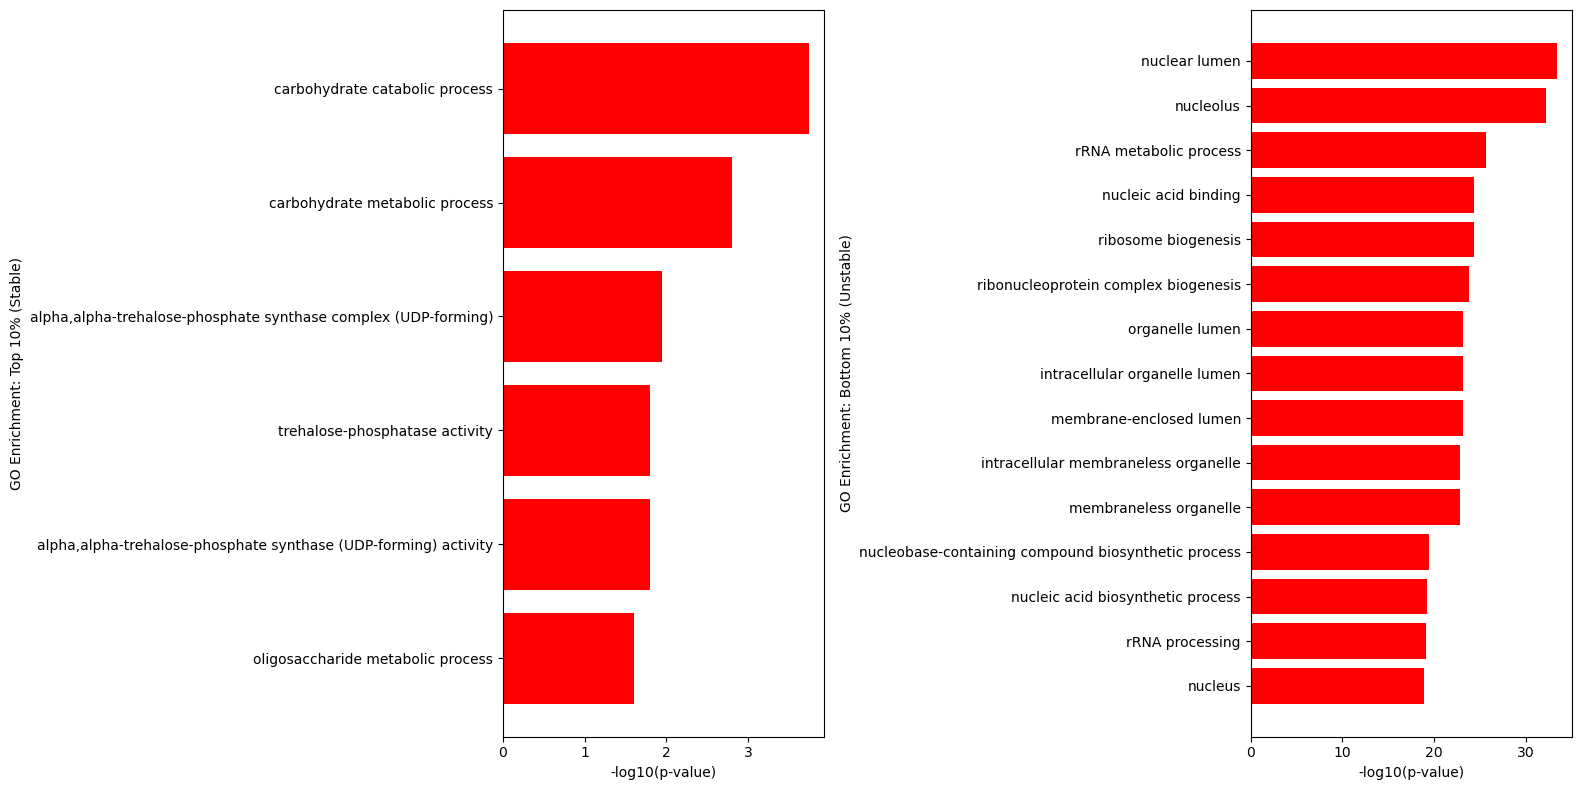

In [15]:
fig, axes = plt.subplots(1, 2, figsize = (16, 8))

for ax, results, title in zip(axes, [top_10_results, bottom_10_results], ['Top 10% (Stable)', 'Bottom 10% (Unstable)']):
    if len(results) > 0:
        plot_data = results.head(15).copy()
        plot_data['-log10(p)'] = -np.log10(plot_data['p_value'])
        plot_data = plot_data.sort_values('-log10(p)')
        
        ax.barh(plot_data['name'], plot_data['-log10(p)'], color = 'red')
        ax.set_xlabel(f'-log10(p-value)')
        ax.set_ylabel(f'GO Enrichment: {title}')
        
    else:
        ax.text(0.5, 0.5, 'No significant terms', ha='center', va='center')
        ax.set_title(f'GO Enrichment: {title}')
plt.tight_layout()
plt.show()

**I tried using GOTermFinder from the provided link but I face a 403 forbidden error, so I went ahead with gProfiler alone.**

#### Gene Ontology Enrichment of Top 10% transcripts

1. The most stable transcripts are involved in carbohydrate metabolism, particularly trehalose biosynthesis. Trehalose is a sugar that yeast uses to protect itself during stress conditions like heat or nutrient starvation. All 4 genes that make up the trehalose synthesis enzyme complex appear in the top 10%, which means the cell keeps these mRNAs around for a long time so it can quickly produce the protective sugar whenever needed. 
2. More broadly, genes involved in breaking down and processing sugars (the main energy source for yeast) also tend to be stable, since the cell needs these processes running continuously.

#### Gene Ontology Enrichment of Bottom 10% transcripts

1. The least stable transcripts are mostly genes involved in building ribosomes — the molecular machines that make proteins. Terms like nucleolus, ribosome biogenesis, and rRNA processing all point to the same process: constructing new ribosomes inside the cell. The extremely low p-values (as low as 10⁻³⁴) show this is a very strong and consistent pattern. 
2. The biological reason makes intuitive sense — ribosome production is extremely costly for the cell, and the cell needs to be able to turn it off quickly when nutrients run low or conditions become unfavorable. By keeping these mRNAs short-lived, the cell can rapidly slow down ribosome production simply by stopping transcription, without having to actively destroy the proteins already made.